#Assignment 4:

##Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

##Set Parameters

In [2]:
# Training configuration
Z_DIM = 100
BATCH_SIZE = 128
NUM_EPOCHS = 25
LR = 0.0002

IMG_CHANNELS = 1
IMG_SIZE = 28

# Use GPU when it is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)

# Keep the same random input for checking progress
preview_noise = torch.randn(16, Z_DIM, 1, 1).to(device)

Training device: cuda


##Load Fashion-MNIST

In [3]:
# Convert images to tensors and normalize them to [-1, 1]
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=preprocess
)

train_loader = torch.utils.data.DataLoader(
    fashion_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Number of training images:", len(fashion_data))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.89MB/s]

Number of training images: 60000


##Display Real Images

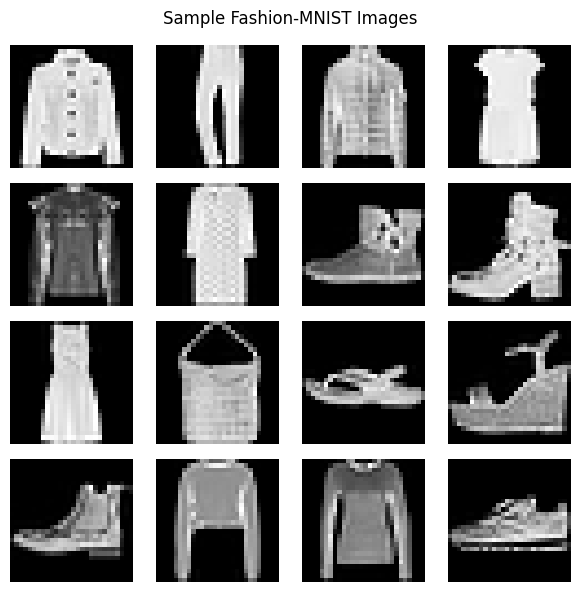

In [4]:
real_batch, _ = next(iter(train_loader))

plt.figure(figsize=(6, 6))

for idx in range(16):
    plt.subplot(4, 4, idx + 1)

    image = real_batch[idx].squeeze().numpy()
    image = (image + 1) / 2

    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

##Generator

In [5]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # 100 x 1 x 1 -> 256 x 4 x 4
            nn.ConvTranspose2d(Z_DIM, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 4 x 4 -> 128 x 8 x 8
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 8 x 8 -> 64 x 16 x 16
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 16 x 16 -> 1 x 28 x 28
            nn.ConvTranspose2d(64, IMG_CHANNELS, 4, 2, 3),
            nn.Tanh()
        )

    def forward(self, noise):
        return self.network(noise)


G = Generator().to(device)

print(G)

Generator(
  (network): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(3, 3))
    (10): Tanh()
  )
)


##Test Generator Before Training

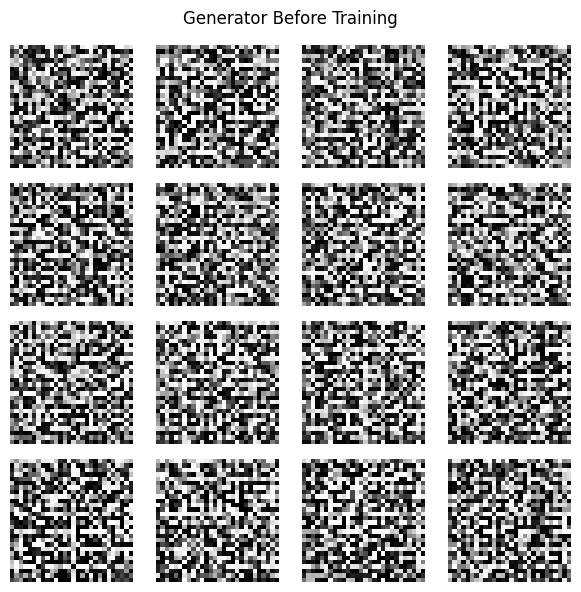

In [6]:
with torch.no_grad():
    initial_images = G(preview_noise)

plt.figure(figsize=(6, 6))

for idx in range(16):
    plt.subplot(4, 4, idx + 1)

    image = initial_images[idx].squeeze().cpu().numpy()
    image = (image + 1) / 2

    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Generator Before Training")
plt.tight_layout()
plt.show()

##Discriminator

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # 28 x 28 -> 14 x 14
            nn.Conv2d(IMG_CHANNELS, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 14 x 14 -> 7 x 7
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 7 x 7 -> 4 x 4
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 x 4 -> 1 x 1
            nn.Conv2d(256, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, image):
        result = self.network(image)
        return result.view(-1)


D = Discriminator().to(device)

print(D)

Discriminator(
  (network): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1))
    (9): Sigmoid()
  )
)


##Loss and Optimizers

In [8]:
criterion = nn.BCELoss()

g_optimizer = optim.Adam(
    G.parameters(),
    lr=LR,
    betas=(0.5, 0.999)
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=LR,
    betas=(0.5, 0.999)
)

print("GAN loss and optimizers are ready.")

GAN loss and optimizers are ready.


##Training the DCGAN

Epoch 01/25 | D Loss: 0.6630 | G Loss: 2.3297
Epoch 02/25 | D Loss: 0.8968 | G Loss: 1.6107
Epoch 03/25 | D Loss: 0.9651 | G Loss: 1.4404
Epoch 04/25 | D Loss: 0.9708 | G Loss: 1.4373
Epoch 05/25 | D Loss: 0.9568 | G Loss: 1.4798


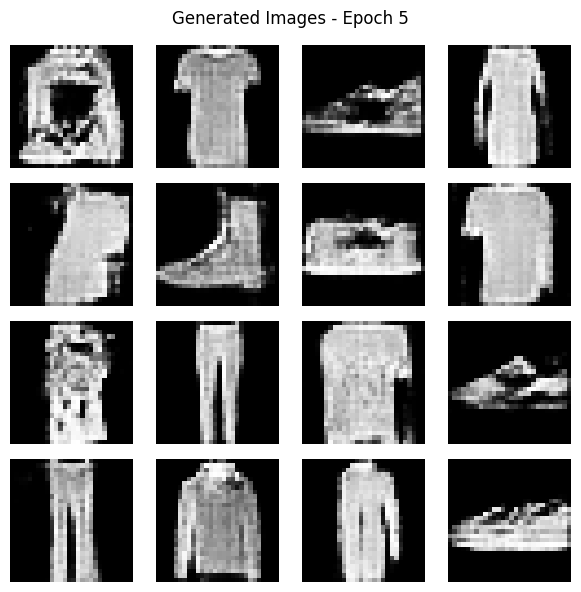

Epoch 06/25 | D Loss: 0.9497 | G Loss: 1.4974
Epoch 07/25 | D Loss: 0.9376 | G Loss: 1.5427
Epoch 08/25 | D Loss: 0.9133 | G Loss: 1.5702
Epoch 09/25 | D Loss: 0.8873 | G Loss: 1.6112
Epoch 10/25 | D Loss: 0.8721 | G Loss: 1.6677


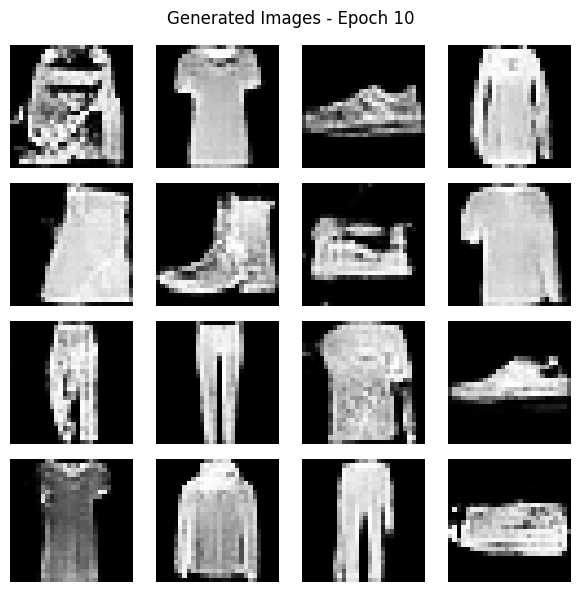

Epoch 11/25 | D Loss: 0.8467 | G Loss: 1.7042
Epoch 12/25 | D Loss: 0.8191 | G Loss: 1.7559
Epoch 13/25 | D Loss: 0.8150 | G Loss: 1.7799
Epoch 14/25 | D Loss: 0.7845 | G Loss: 1.8389
Epoch 15/25 | D Loss: 0.7850 | G Loss: 1.8743


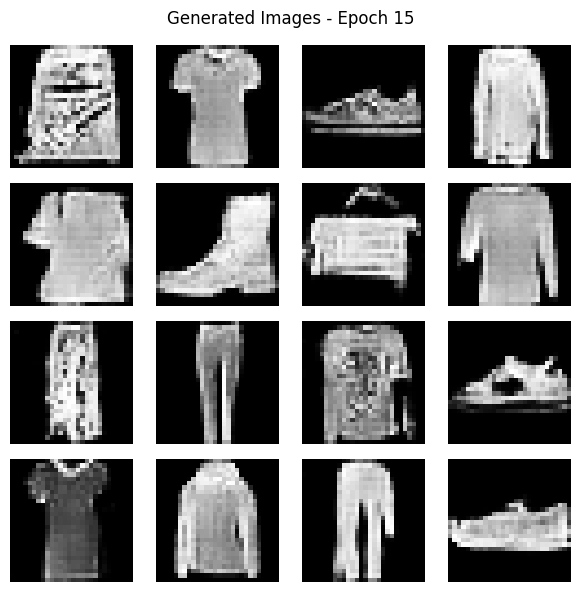

Epoch 16/25 | D Loss: 0.7674 | G Loss: 1.8772
Epoch 17/25 | D Loss: 0.7424 | G Loss: 1.9417
Epoch 18/25 | D Loss: 0.7486 | G Loss: 1.9680
Epoch 19/25 | D Loss: 0.7071 | G Loss: 2.0270
Epoch 20/25 | D Loss: 0.6988 | G Loss: 2.0641


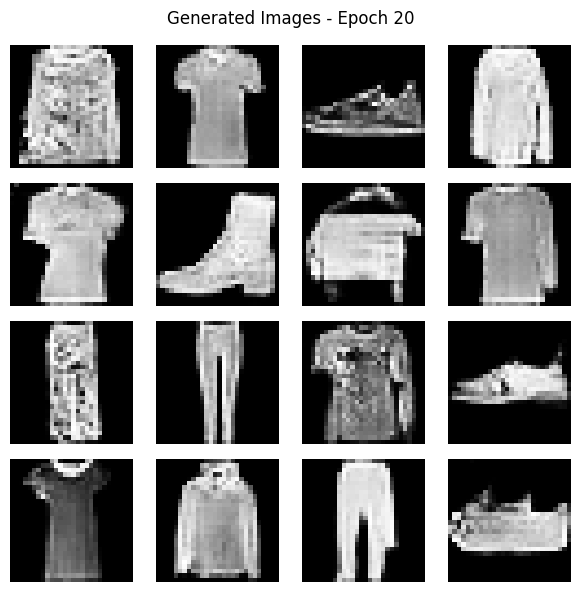

Epoch 21/25 | D Loss: 0.6972 | G Loss: 2.0817
Epoch 22/25 | D Loss: 0.6713 | G Loss: 2.1298
Epoch 23/25 | D Loss: 0.6761 | G Loss: 2.1656
Epoch 24/25 | D Loss: 0.6300 | G Loss: 2.2102
Epoch 25/25 | D Loss: 0.6266 | G Loss: 2.2698


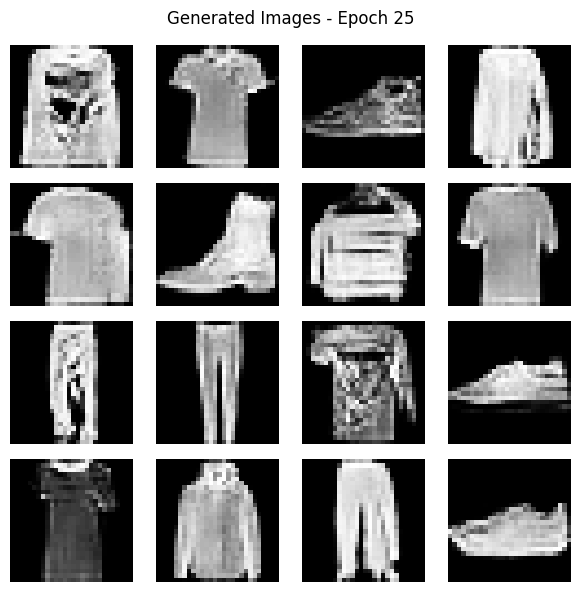

In [9]:
generator_history = []
discriminator_history = []

for epoch in range(NUM_EPOCHS):

    total_g_loss = 0.0
    total_d_loss = 0.0

    for real_data, _ in train_loader:

        real_data = real_data.to(device)
        current_batch = real_data.size(0)

        # Labels for real and generated images
        real_targets = torch.ones(current_batch, device=device)
        fake_targets = torch.zeros(current_batch, device=device)

        # -------------------------
        # Train Discriminator
        # -------------------------
        d_optimizer.zero_grad()

        real_prediction = D(real_data)
        real_loss = criterion(real_prediction, real_targets)

        random_input = torch.randn(
            current_batch, Z_DIM, 1, 1, device=device
        )

        generated_data = G(random_input)

        fake_prediction = D(generated_data.detach())
        fake_loss = criterion(fake_prediction, fake_targets)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_optimizer.step()

        # -------------------------
        # Train Generator
        # -------------------------
        g_optimizer.zero_grad()

        generator_prediction = D(generated_data)

        g_loss = criterion(
            generator_prediction,
            real_targets
        )

        g_loss.backward()
        g_optimizer.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    # Calculate average loss for the epoch
    avg_d_loss = total_d_loss / len(train_loader)
    avg_g_loss = total_g_loss / len(train_loader)

    discriminator_history.append(avg_d_loss)
    generator_history.append(avg_g_loss)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"D Loss: {avg_d_loss:.4f} | "
        f"G Loss: {avg_g_loss:.4f}"
    )

    # Generate a preview after every 5 epochs
    if (epoch + 1) % 5 == 0:

        with torch.no_grad():
            preview_images = G(preview_noise)

        plt.figure(figsize=(6, 6))

        for idx in range(16):
            plt.subplot(4, 4, idx + 1)

            image = preview_images[idx].squeeze().cpu().numpy()
            image = (image + 1) / 2

            plt.imshow(image, cmap="gray")
            plt.axis("off")

        plt.suptitle(
            f"Generated Images - Epoch {epoch + 1}"
        )
        plt.tight_layout()

        plt.savefig(
            f"fashion_gan_epoch_{epoch + 1}.png"
        )

        plt.show()

##Generate New Images After Training

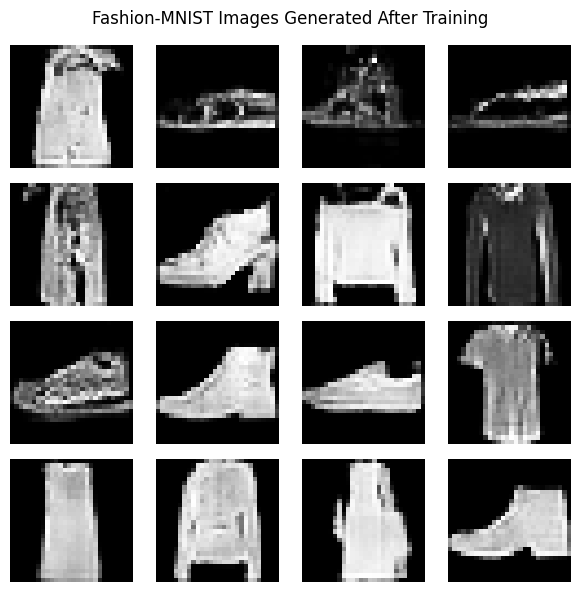

In [10]:
# Use completely new random noise
new_noise = torch.randn(
    16, Z_DIM, 1, 1, device=device
)

with torch.no_grad():
    final_images = G(new_noise)

plt.figure(figsize=(6, 6))

for idx in range(16):
    plt.subplot(4, 4, idx + 1)

    image = final_images[idx].squeeze().cpu().numpy()
    image = (image + 1) / 2

    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Fashion-MNIST Images Generated After Training")
plt.tight_layout()
plt.show()

##plot graph


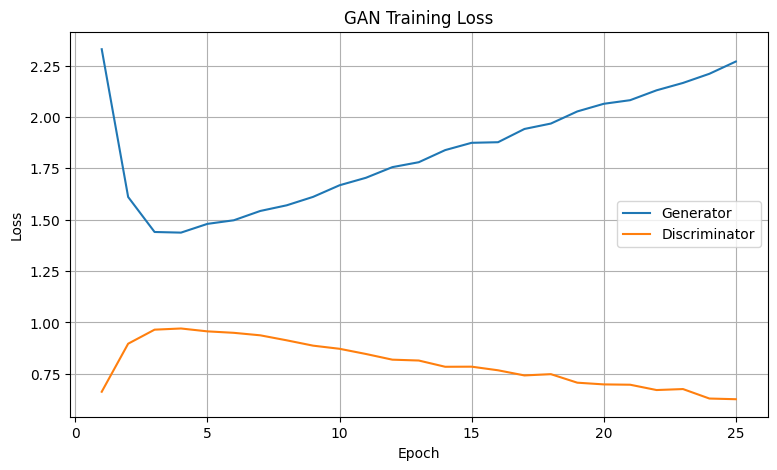

In [25]:
epochs_axis = range(1, len(generator_history) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_axis, generator_history, label="Generator")
plt.plot(range(1, len(discriminator_history) + 1), discriminator_history, label="Discriminator")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

1. How do the images change from epoch 5 to epoch 25?

By epoch 5, the generator has already picked up the basic silhouettes of shirts, shoes, and trousers, though the outlines are still soft and somewhat grainy. Over the next 20 epochs, those same categories persist — the generator doesn't lose or gain new clothing types — but the rendering quality improves: edges tighten up, the black background becomes more uniformly dark, and each garment's shape reads more distinctly against it. So the change is less about learning new content and more about refining the same content.

2. Is there any sign of instability during training?

Yes. The discriminator loss climbs from about 0.73 to roughly 1.0 over the first three epochs, then steadily falls to about 0.64 by epoch 25 — it's getting progressively better at catching fakes. The generator loss moves the opposite way: it dips from 2.22 to 1.39 early on, then climbs back up to about 2.22 by the end. That's the discriminator pulling ahead while the generator falls behind, and the two losses never settle into a shared equilibrium — a mild instability pattern, though not severe enough to cause mode collapse, since the outputs stay visually varied and recognizable throughout.

3. At what point do the clothing shapes become recognizable?

Remarkably early — by epoch 5, shirts, shoes, and trousers are already identifiable. That's likely a product of Fashion-MNIST itself being a fairly easy dataset for a GAN: simple silhouettes, consistent black backgrounds, and low resolution, all of which make the categories easy to pick up quickly.

4. Does image quality keep improving all the way to epoch 25?

Not really past epoch 15. Epochs 15, 20, and 25 look nearly the same structurally, with only small sharpening differences — quality plateaus around epoch 15 rather than climbing steadily. A couple of outputs (third row, third and fourth columns) stayed noisy and unclear even at epoch 25, suggesting the generator never fully nailed those particular categories.